Python executable (uv-managed venv): d:\MCMC_PMB\.venv\Scripts\python.exe
Saved standard-case dataset -> d:\MCMC_PMB\data\standard_case.csv


d:\MCMC_PMB\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sequential sampling (1 chains in 1 job)
CompoundStep
>Metropolis: [theta_raw]
>Metropolis: [Np_true]
>Metropolis: [Rp_true]
>Metropolis: [nu]


d:\MCMC_PMB\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 1 chain for 3_000 tune and 9_000 draw iterations (3_000 + 9_000 draws total) took 1619 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


d:\MCMC_PMB\.venv\Lib\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

...


=== Bayesian 90% HDI Contains Truth? ===


,Method,N in 90% HDI,m in 90% HDI,J in 90% HDI
0,Metropolis-Hastings,True,True,True
1,NUTS,True,True,True



=== Point Estimates (Straw-Man vs Bayesian Medians) ===


,Method,N,m,J
0,Truth,110.000,0.350,15.000
1,Havlena-Odeh,144.590,0.524,0.000
2,MH (Posterior Median),123.525,0.366,10.096
3,NUTS (Posterior Median),124.719,0.373,9.277


C:\Users\0xRust\AppData\Local\Temp\ipykernel_6008\2434575548.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Method", y="Time (s)", ax=axes[0], palette="Blues_d")
C:\Users\0xRust\AppData\Local\Temp\ipykernel_6008\2434575548.py:256: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Method", y="Accuracy (Pressure RMSE, psi)", ax=axes[1], palette="Greens_d")
C:\Users\0xRust\AppData\Local\Temp\ipykernel_6008\2434575548.py:262: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ess_plot, x="Method", y="ES

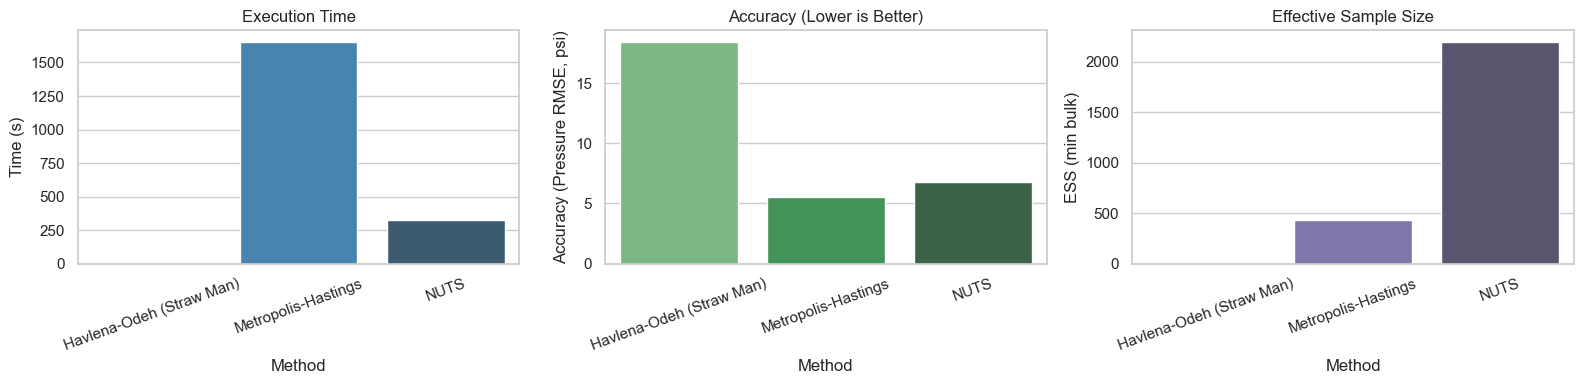

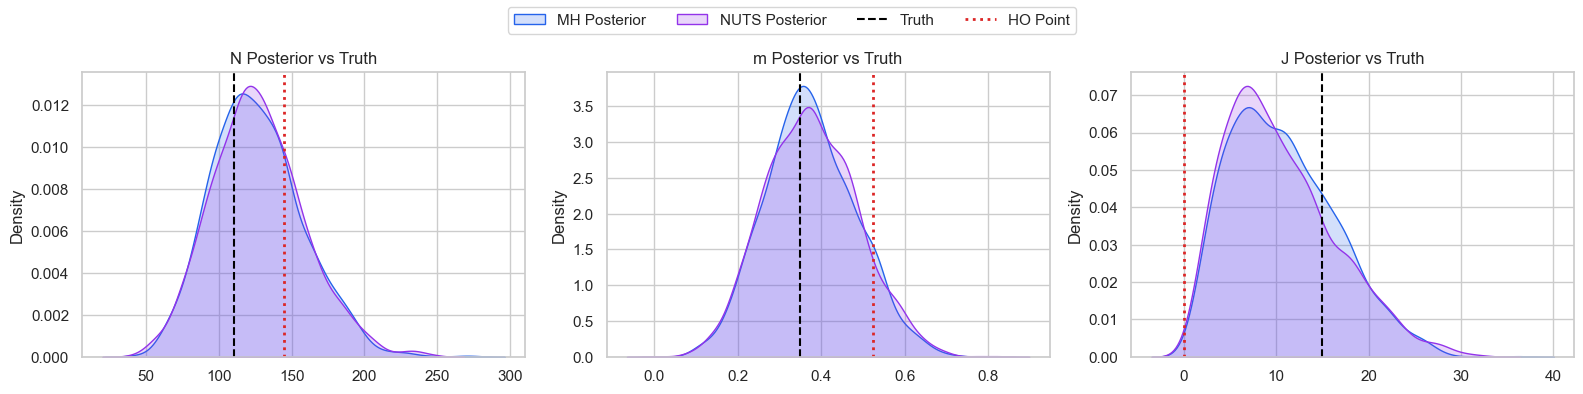


Saved CSV results in: d:\MCMC_PMB\outputs\research


In [1]:
import sys
import time
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mcmc_pmb.forward_model import MaterialBalanceModel, prepare_production_dataset
from mcmc_pmb.mcmc import MetropolisHastingsConfig, NUTSConfig
from mcmc_pmb.priors import PriorParameters
from mcmc_pmb.pvt import MaterialBalancePVT
from mcmc_pmb.pymc_model import run_sampler
from mcmc_pmb.synthetic import generate_synthetic_dataset

sns.set_theme(style="whitegrid")

TRUE = {"N": 110.0, "m": 0.35, "J": 15.0}
NOISE = 50.0

print(f"Python executable (uv-managed venv): {sys.executable}")

# 1) Generate Standard Case synthetic dataset (moderate noise, standard aquifer)
data_path = ROOT / "data" / "standard_case.csv"
df = generate_synthetic_dataset(
    output_csv=data_path,
    n_steps=24,
    true_parameters=(TRUE["N"], TRUE["m"]),
    measurement_noise=NOISE,
    aquifer_J=TRUE["J"],
    random_seed=2026,
    max_prod=12.0e6,
)
print(f"Saved standard-case dataset -> {data_path}")

# Shared modeling objects
pvt_params = MaterialBalancePVT()
model = MaterialBalanceModel(pvt_params=pvt_params)
dataset = prepare_production_dataset(df)
predict_fn = model.make_predict_function(dataset)

prior = PriorParameters(
    mean_N=100.0,
    mean_m=0.4,
    mean_J=np.log(max(TRUE["J"], 1e-9)),
    std_N=60.0,
    std_m=0.13,
    std_J=1.0,
    correlation=-0.5,
)


def havlena_odeh_linear_regression(data: pd.DataFrame, pvt: MaterialBalancePVT) -> dict:
    """
    Simple HO straw-man:
      F = N(Eo + m*Eg) + We
      -> (ignoring We) y = F/Eo = N + (mN)*(Eg/Eo)
    We then estimate N (intercept) and m = slope / intercept.
    """
    engine = pvt.build_engine()

    pressure = data["Pressure_measured"].to_numpy(dtype=float)
    Np = data["Np"].to_numpy(dtype=float)
    Rp = data["Rp"].to_numpy(dtype=float)
    Wp = data["Wp"].to_numpy(dtype=float)

    Bo, _ = engine.oil_fvf_numpy(pressure)
    Bg, _ = engine.gas_fvf_numpy(pressure)
    Rs, _ = engine.solution_gor_numpy(pressure)

    Boi = engine.oil_at_initial
    Bgi = max(engine.gas_at_initial, 1e-12)
    Rsi = engine.rs_at_initial
    Bw = 1.0

    Eo = (Bo - Boi) + (Rsi - Rs) * Bg
    Eg = Boi * ((Bg / Bgi) - 1.0)
    F = Np * (Bo + (Rp - Rs) * Bg) + Wp * Bw

    mask = np.isfinite(Eo) & np.isfinite(Eg) & np.isfinite(F) & (np.abs(Eo) > 1e-9) & (Np > 0)
    x = Eg[mask] / Eo[mask]
    y = F[mask] / Eo[mask]

    A = np.column_stack([np.ones_like(x), x])
    intercept_stb, slope = np.linalg.lstsq(A, y, rcond=None)[0]

    intercept_stb = max(float(intercept_stb), 1e-6)
    m_hat = max(float(slope / intercept_stb), 0.0)

    return {
        "N": intercept_stb / 1.0e6,
        "m": m_hat,
        "J": 0.0,
    }


def min_bulk_ess(chain: np.ndarray) -> float:
    idata = az.from_dict(
        posterior={
            "N": chain[None, :, 0],
            "m": chain[None, :, 1],
            "J": chain[None, :, 2],
        }
    )
    ess_ds = az.ess(idata, method="bulk")
    return float(
        min(
            ess_ds["N"].values.item(),
            ess_ds["m"].values.item(),
            ess_ds["J"].values.item(),
        )
    )


def pressure_rmse(theta: np.ndarray) -> float:
    pred = predict_fn(theta.astype(float))
    return float(np.sqrt(np.mean((pred - dataset.pressure_truth) ** 2)))


def parameter_hdi_coverage(chain: np.ndarray, truth: dict, hdi_prob: float = 0.9) -> dict:
    coverage = {}
    intervals = {}
    for i, name in enumerate(["N", "m", "J"]):
        hdi = az.hdi(chain[:, i], hdi_prob=hdi_prob)
        lo, hi = float(hdi[0]), float(hdi[1])
        intervals[name] = (lo, hi)
        coverage[name] = lo <= truth[name] <= hi
    return {"contains": coverage, "intervals": intervals}


# 2) Havlena-Odeh Straw-Man (deterministic single estimate)
t0 = time.perf_counter()
ho_theta = havlena_odeh_linear_regression(df, pvt_params)
ho_time = time.perf_counter() - t0
ho_vec = np.array([ho_theta["N"], ho_theta["m"], ho_theta["J"]], dtype=float)
ho_rmse = pressure_rmse(ho_vec)

# 3) Metropolis-Hastings
mh_cfg = MetropolisHastingsConfig(
    n_iterations=12000,
    burn_in=3000,
    thinning=5,
    proposal_std=(3.0, 0.03, 0.25),
    use_adaptive=True,
    random_seed=2026,
)

t0 = time.perf_counter()
mh_result = run_sampler(mh_cfg, prior, dataset, model, sigma=100.0, sampler_type="metropolis")
mh_time = time.perf_counter() - t0
mh_chain = mh_result.chain
mh_theta = np.median(mh_chain, axis=0)
mh_rmse = pressure_rmse(mh_theta)
mh_ess = min_bulk_ess(mh_chain)
mh_cov = parameter_hdi_coverage(mh_chain, TRUE, hdi_prob=0.9)

# 4) NUTS
nuts_cfg = NUTSConfig(
    n_samples=1000,
    n_tune=1000,
    target_accept=0.9,
    max_treedepth=10,
    random_seed=2026,
    n_chains=2,
)

t0 = time.perf_counter()
nuts_result = run_sampler(nuts_cfg, prior, dataset, model, sigma=100.0, sampler_type="nuts")
nuts_time = time.perf_counter() - t0
nuts_chain = nuts_result.chain
nuts_theta = np.median(nuts_chain, axis=0)
nuts_rmse = pressure_rmse(nuts_theta)
nuts_ess = min_bulk_ess(nuts_chain)
nuts_cov = parameter_hdi_coverage(nuts_chain, TRUE, hdi_prob=0.9)

# 5) Comparison table: Time vs Accuracy vs ESS
comparison = pd.DataFrame(
    [
        {
            "Method": "Havlena-Odeh (Straw Man)",
            "Time (s)": ho_time,
            "Accuracy (Pressure RMSE, psi)": ho_rmse,
            "ESS (min bulk)": np.nan,
        },
        {
            "Method": "Metropolis-Hastings",
            "Time (s)": mh_time,
            "Accuracy (Pressure RMSE, psi)": mh_rmse,
            "ESS (min bulk)": mh_ess,
        },
        {
            "Method": "NUTS",
            "Time (s)": nuts_time,
            "Accuracy (Pressure RMSE, psi)": nuts_rmse,
            "ESS (min bulk)": nuts_ess,
        },
    ]
)

coverage_table = pd.DataFrame(
    [
        {
            "Method": "Metropolis-Hastings",
            "N in 90% HDI": mh_cov["contains"]["N"],
            "m in 90% HDI": mh_cov["contains"]["m"],
            "J in 90% HDI": mh_cov["contains"]["J"],
        },
        {
            "Method": "NUTS",
            "N in 90% HDI": nuts_cov["contains"]["N"],
            "m in 90% HDI": nuts_cov["contains"]["m"],
            "J in 90% HDI": nuts_cov["contains"]["J"],
        },
    ]
)

research_out = ROOT / "outputs" / "research"
research_out.mkdir(parents=True, exist_ok=True)
comparison.to_csv(research_out / "comparison_table.csv", index=False)
coverage_table.to_csv(research_out / "coverage_table.csv", index=False)

# Add deterministic parameter bias view for straw-man vs Bayesian medians
param_table = pd.DataFrame(
    [
        {"Method": "Truth", "N": TRUE["N"], "m": TRUE["m"], "J": TRUE["J"]},
        {"Method": "Havlena-Odeh", "N": ho_vec[0], "m": ho_vec[1], "J": ho_vec[2]},
        {"Method": "MH (Posterior Median)", "N": mh_theta[0], "m": mh_theta[1], "J": mh_theta[2]},
        {"Method": "NUTS (Posterior Median)", "N": nuts_theta[0], "m": nuts_theta[1], "J": nuts_theta[2]},
    ]
)
param_table.to_csv(research_out / "parameter_estimates.csv", index=False)

print("\n=== Comparison: Time vs Accuracy vs ESS ===")
display(comparison.round(3))

print("\n=== Bayesian 90% HDI Contains Truth? ===")
display(coverage_table)

print("\n=== Point Estimates (Straw-Man vs Bayesian Medians) ===")
display(param_table.round(3))

# 6) Graphs
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=comparison, x="Method", y="Time (s)", ax=axes[0], palette="Blues_d")
axes[0].set_title("Execution Time")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=comparison, x="Method", y="Accuracy (Pressure RMSE, psi)", ax=axes[1], palette="Greens_d")
axes[1].set_title("Accuracy (Lower is Better)")
axes[1].tick_params(axis="x", rotation=20)

ess_plot = comparison.copy()
ess_plot["ESS (min bulk)"] = ess_plot["ESS (min bulk)"].fillna(0.0)
sns.barplot(data=ess_plot, x="Method", y="ESS (min bulk)", ax=axes[2], palette="Purples_d")
axes[2].set_title("Effective Sample Size")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# Posterior distributions vs truth + straw-man point
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, name in enumerate(["N", "m", "J"]):
    sns.kdeplot(mh_chain[:, idx], ax=axes[idx], label="MH Posterior", color="#2563eb", fill=True, alpha=0.2)
    sns.kdeplot(nuts_chain[:, idx], ax=axes[idx], label="NUTS Posterior", color="#9333ea", fill=True, alpha=0.2)
    axes[idx].axvline(TRUE[name], color="black", linestyle="--", linewidth=1.5, label="Truth")
    axes[idx].axvline(ho_theta[name], color="#dc2626", linestyle=":", linewidth=2, label="HO Point")
    axes[idx].set_title(f"{name} Posterior vs Truth")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print(f"\nSaved CSV results in: {research_out}")